<a href="https://colab.research.google.com/github/Kostyamops/ml-itmo/blob/main/lab1_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Функции (3 балла)

##1.1

Постройте график функции и её производной первого порядка. Также найдите точки экстремума функции, отметьте их на графике другим цветом. Вычисления проведите вручную и приложите скрин расчетов.

$f(x) = (x^2-2x)ln(x)-1.5x^2+4x$


<расчет производной, нужно вставить фото или записать с помощью LaTeX>
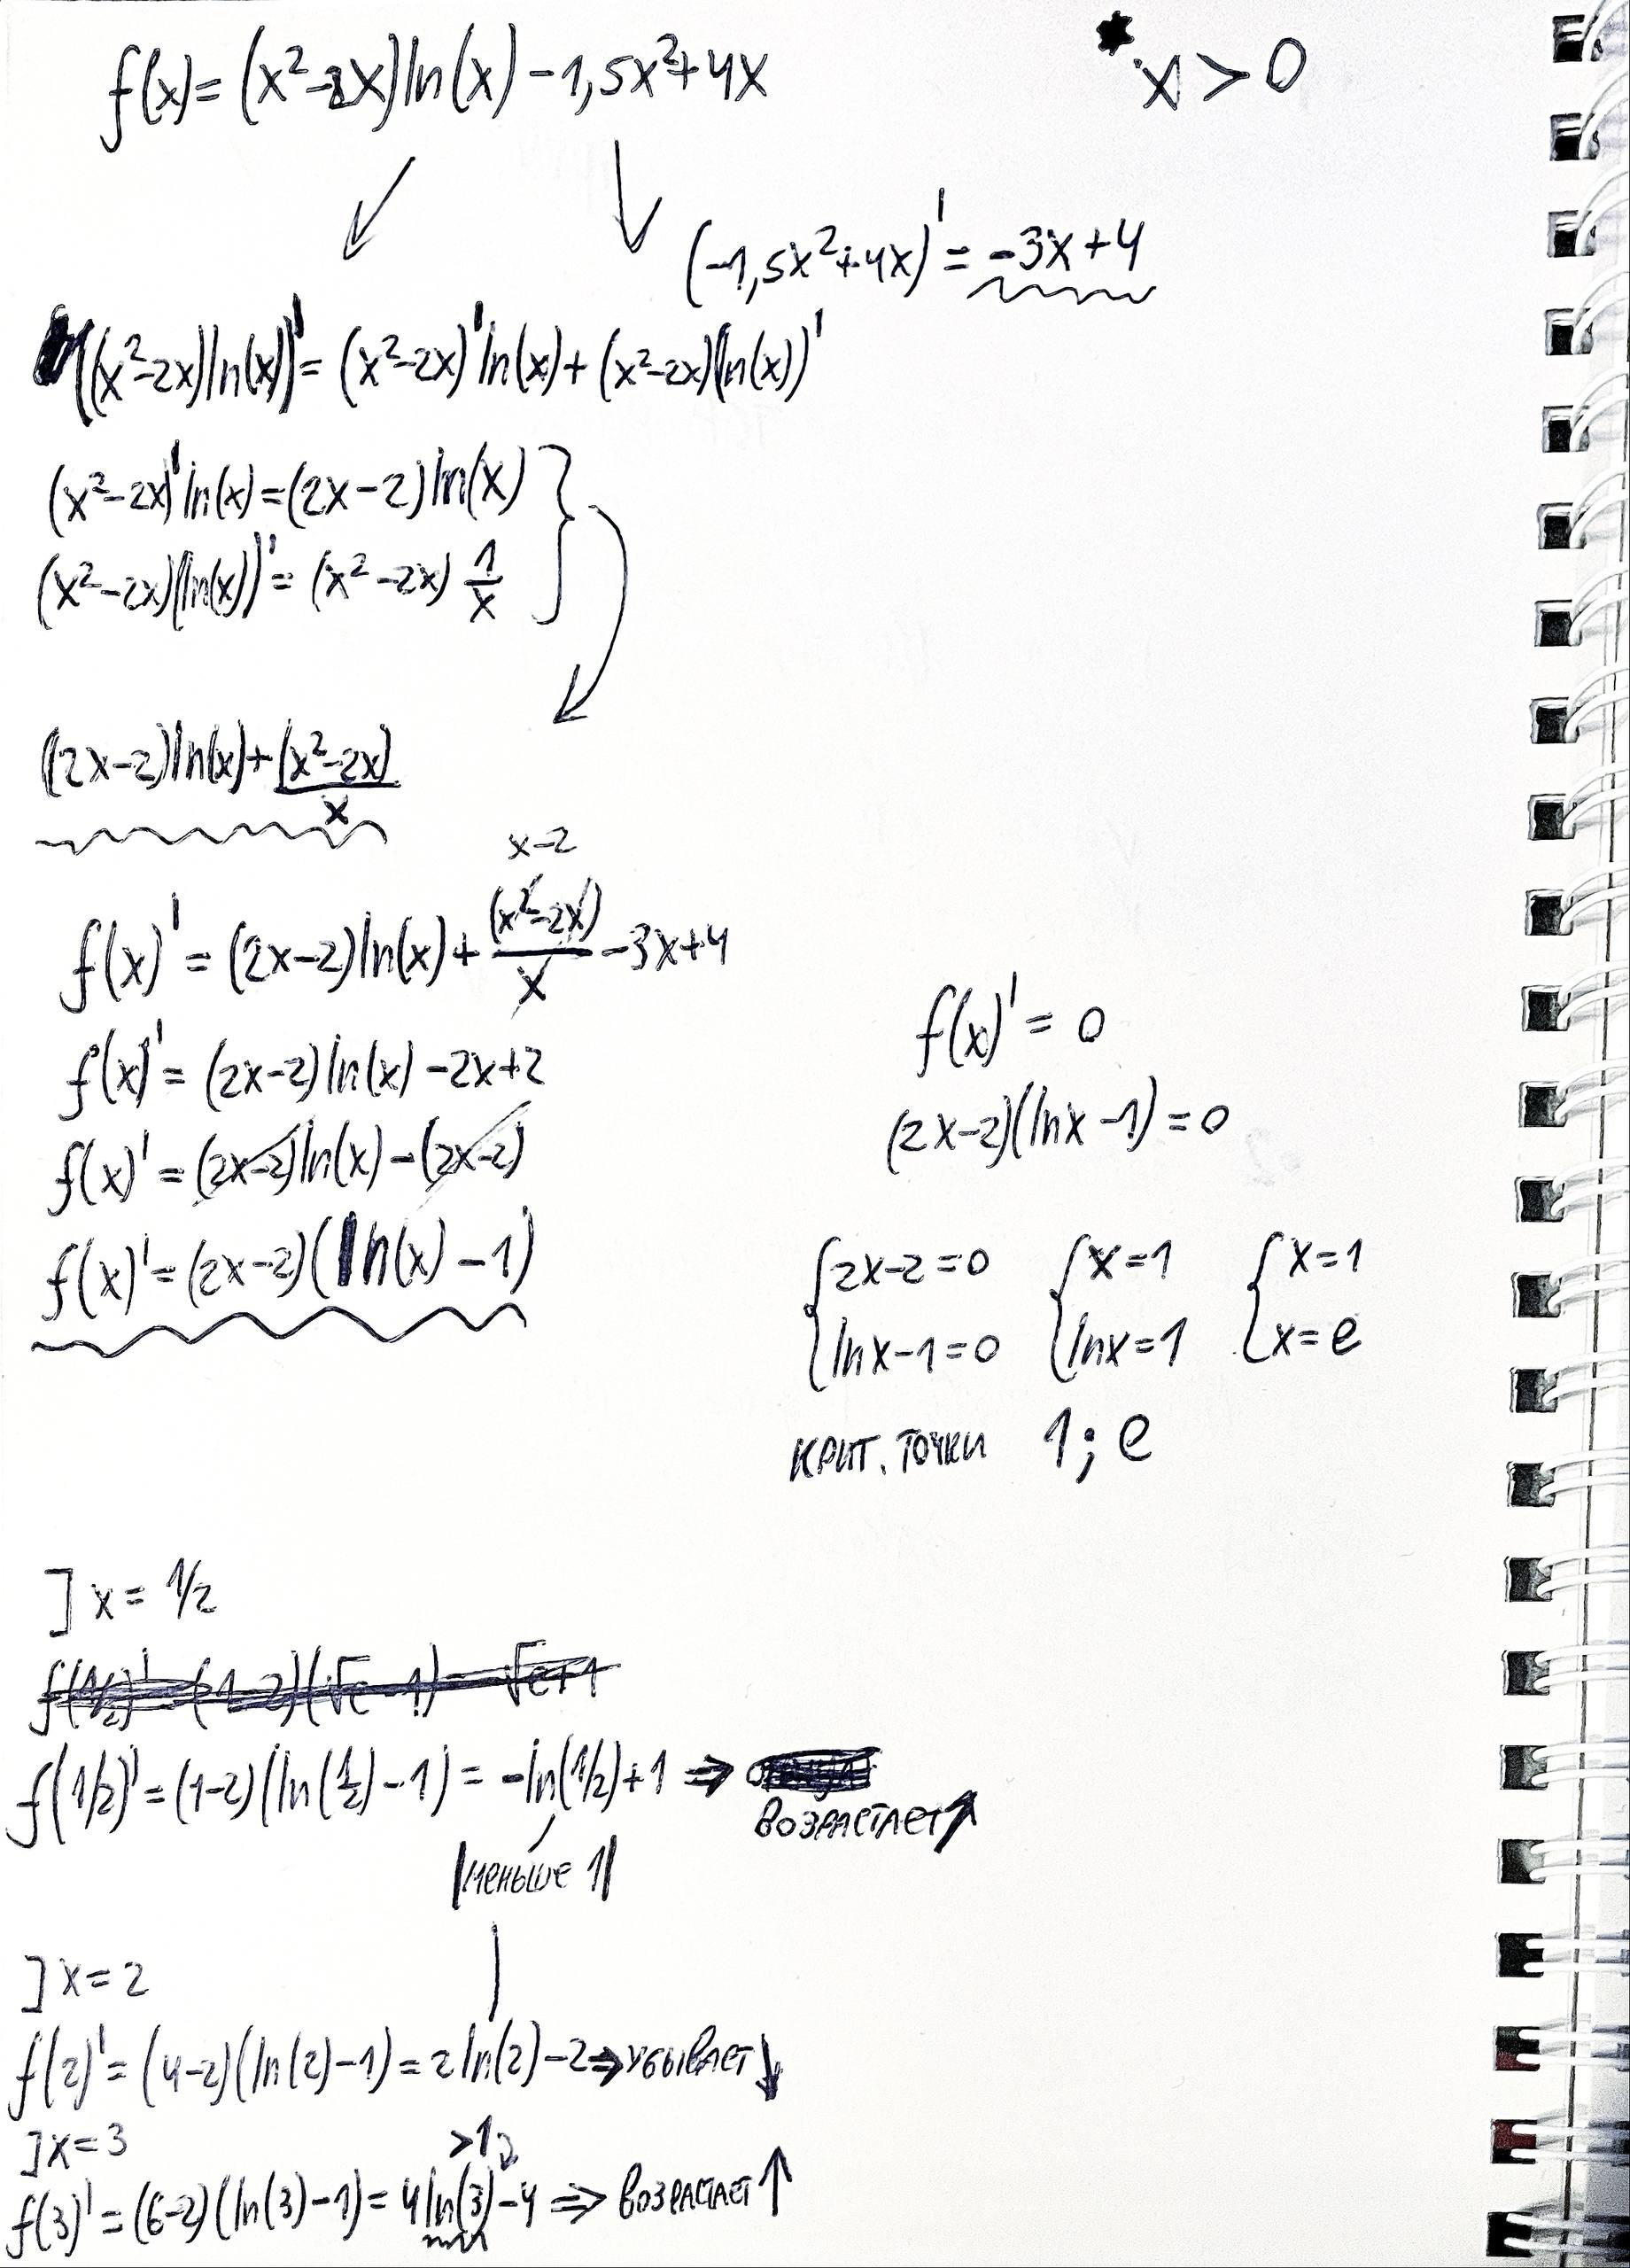

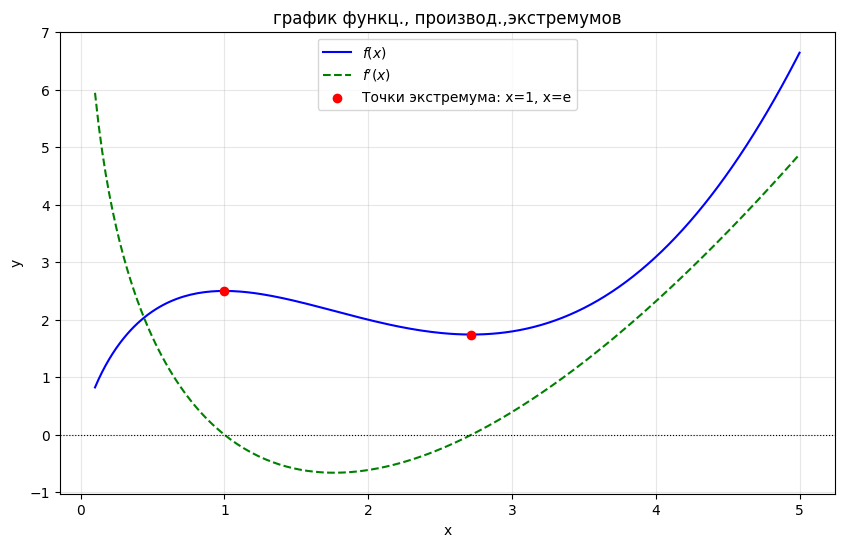

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def f(x):
    return (x**2 - 2 * x) * np.log(x) - 1.5 * x**2 + 4 * x


def f_dx(x):
    return (2 * x - 2) * np.log(x) - 2 * x + 2


x_values = np.linspace(0.1, 5, 200)

# Точки экстремума
extrema_x = np.array([1.0, np.e])
extrema_y = f(extrema_x)

plt.figure(figsize=(10, 6))
plt.plot(x_values, f(x_values), label="$f(x)$", color="blue")
plt.plot(x_values, f_dx(x_values), label="$f'(x)$", color="green", linestyle="--")
plt.scatter(
    extrema_x, extrema_y, color="red", zorder=5, label="Точки экстремума: x=1, x=e"
)
plt.axhline(0, color="black", linewidth=0.8, linestyle=":")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("график функц., производ.,экстремумов")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

##1.2

Найдите частные производные функции $f(x, y, z) = 15x^2 + exp(x^2 + y^3)*cos(z)$ с помощью [SymPy](https://www.geeksforgeeks.org/python-sympy-diff-method/)

In [3]:
import sympy as sp

x, y, z = sp.symbols("x y z")
f_expr = 15 * x**2 + sp.exp(x**2 + y**3) * sp.cos(z)

df_dx = sp.diff(f_expr, x)
df_dy = sp.diff(f_expr, y)
df_dz = sp.diff(f_expr, z)

print("df/dx =", df_dx)
print("df/dy =", df_dy)
print("df/dz =", df_dz)

df/dx = 2*x*exp(x**2 + y**3)*cos(z) + 30*x
df/dy = 3*y**2*exp(x**2 + y**3)*cos(z)
df/dz = -exp(x**2 + y**3)*sin(z)


##2

Не всегда значения функций возможно рассчитать напрямую, однако их можно вычислить приближенно, используя, например, ряды Тейлора. Реализуйте расчет $e^x$. Сравните значения, получаемые с различной точностью приближения (5, 10, 15), с numpy-реализацией. Постройте график, отобразив на нём все четыре линии.

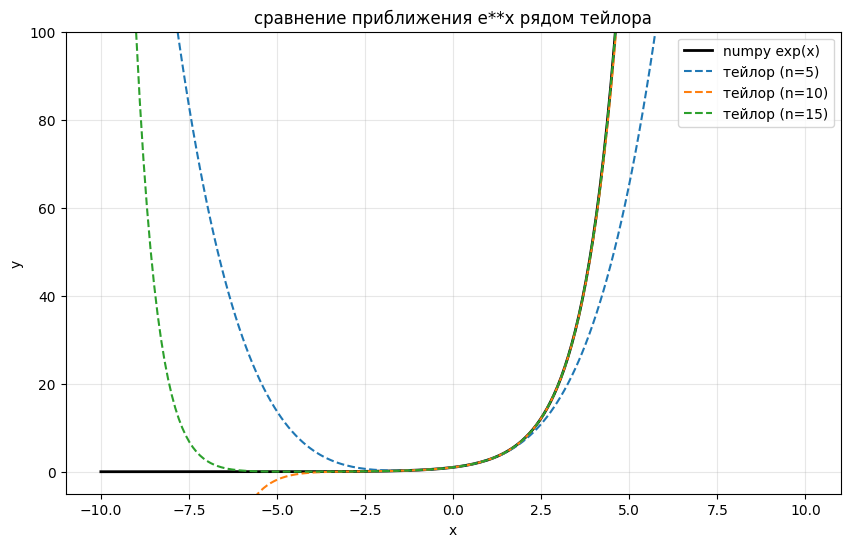

In [4]:
x_values = np.linspace(-10, 10, 200)

import math


def exp_taylor(x, n_terms):
    return sum((x**k) / math.factorial(k) for k in range(n_terms))

plt.figure(figsize=(10, 6))
plt.plot(x_values, np.exp(x_values), label="numpy exp(x)", color="black", lw=2)

for n in [5, 10, 15]:
    y_taylor = [exp_taylor(xi, n) for xi in x_values]
    plt.plot(x_values, y_taylor, label=f"тейлор (n={n})", linestyle="--")

plt.ylim(-5, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("сравнение приближения e**x рядом тейлора")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

##3

Рассмотрите две следующие функции, часто использующиеся как функции потерь (то есть они помогают оценить качество предсказаний модели).

$MAE (Mean\ Absolute\ Error) = \frac{1}{n} \sum_{i=1}^{n} |y_i - \widehat{y}_i|$

$MSE (Mean\ Squared\ Error) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$

Письменно ответьте на вопросы:

1. Какая проблема присуща MAE с точки зрения дифференцирования?

2. Если в качестве $\widehat{y}_i$ всегда будет предсказываться константное значение, каким оно должно быть, чтобы минимизировать значение каждой из функций?


# **Ответы на вопросы**

1.

Главный минус MAE - использование модуля. В точке равенства предсказания и ответа (y=y_hat) график имеет угол где производной не сущ. + модуль производной MAE всегда равен 1 (или -1), из-за чего градиентный спуск не понимает, насколько он близок к оптимуму

2.

Для MAE - медиана выборки y.

Для MSE - выбороч. среднее элементов y.

# Матрицы. Векторы (2 балла)

##1

Реализуйте следующие паттерны. Не используйте циклы! Все матрицы квадратные со стороной длины n. Примеры приведены для n=5.

1. Шахматная доска
```
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]
 ```
2. Полоса шириной 3 относительно главной диагонали
```
[[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]
 ```
3. Кайма из единиц
```
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
 ```
4. Полосы
```
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]
 ```
5. Верхний треугольник
```
[[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]
 ```


In [11]:
n = 5

# шахматы
checkerboard = (
    np.indices((n, n)).sum(axis=0) % 2
).astype(float)

# полоска
band = (np.abs(np.subtract.outer(np.arange(n), np.arange(n))) <= 1).astype(
    float
)

# кайма
border = np.ones((n, n))
border[1:-1, 1:-1] = 0.0

# чередование
stripes = np.tile(np.array([[0.0], [1.0]]), (n // 2 + 1, n))[:n, :]

# верх. треугольник
upper_tri = np.triu(np.ones((n, n)))

print("Шахматная доска:\n", checkerboard)
print("\nПолоса шириной 3:\n", band)
print("\nКайма из единиц:\n", border)
print("\nПолосы:\n", stripes)
print("\nВерхний треугольник:\n", upper_tri)

Шахматная доска:
 [[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]

Полоса шириной 3:
 [[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]

Кайма из единиц:
 [[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Полосы:
 [[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]

Верхний треугольник:
 [[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]


##2

Пусть дан вектор следующего вида. Преобразуйте его, чтобы получить две матрицы: первая должна содержать одинаковые значения column-wise (столбец целиком из нулей, столбец целиком из единиц и так далее), а вторая - row-wise. Не используйте циклы.

In [12]:
n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])  # также существуют vstack и dstack
print(vector)

[0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4]


In [16]:
n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])

# column-wise
col_matrix = vector.reshape(n, n)

# row-wise
row_matrix = vector.reshape(n, n).T

print("column-wise:\n", col_matrix)
print("\nrow-wise:\n", row_matrix)

column-wise:
 [[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]

row-wise:
 [[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]


# Введение в PyTorch (2 балла)

С точки зрения синтаксиса PyTorch похож на NumPy, основная разница заключается в том, что данный фреймворк предназначен для автоматического расчета градиентов. [Вот тут](https://github.com/torch/torch7/wiki/Torch-for-Numpy-users) можно почитать про то, как соотносятся две эти библиотеки.

[Неплохой курс чисто про PyTorch](https://www.learnpytorch.io/)

[Документация PyTorch](https://pytorch.org/)

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision.transforms import transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

##1

1. Создайте два вещественных тензора: $a$ размером (10, 2) и $b$ размером (, 20)

2. Создайте тензор c, являющийся тензором $b$, но размера (2, 2, 5)

3. Выведите первый столбец матрицы $a$ с помощью индексации

4. Создайте тензор $d$, являющийся тензором $b$, но размера (10, 2). Произведите все арифметические операции с тензорами $a$ и $d$

In [17]:
# 1)веществ тензоры a и b
a = torch.randn(10, 2)
b = torch.randn(20)

#2)тензор c размера 2,2,5
c = b.view(2, 2, 5)

# 3)первый столбец матрицы a
first_col = a[:, 0]
print("Первый столбец a:", first_col)

# 4)Тензор d размера(10,2)
d = b.view(10, 2)
print("a + d:\n", a + d)
print("a - d:\n", a - d)
print("a * d:\n", a * d)
print("a / d:\n", a / d)

Первый столбец a: tensor([-0.3693, -1.4208, -0.1118,  0.8227, -0.4931,  1.0296, -2.4722,  2.1953,
         0.9312,  1.0060])
a + d:
 tensor([[-1.2789, -0.8661],
        [-1.6298, -1.0119],
        [-0.5749, -0.1066],
        [-0.6398, -1.6872],
        [-1.0630,  1.2187],
        [ 1.0616,  1.8091],
        [-1.2175,  1.0229],
        [ 2.7786, -1.9596],
        [ 1.0524, -1.1456],
        [-0.7819,  0.1247]])
a - d:
 tensor([[ 0.5404, -0.0213],
        [-1.2119,  0.5895],
        [ 0.3513,  0.5468],
        [ 2.2853, -2.6593],
        [ 0.0768,  1.5977],
        [ 0.9975,  1.1819],
        [-3.7270,  0.5956],
        [ 1.6121, -0.9742],
        [ 0.8100, -1.4402],
        [ 2.7939,  2.9858]])
a * d:
 tensor([[ 0.3359,  0.1874],
        [ 0.2969,  0.1691],
        [ 0.0518, -0.0719],
        [-1.2033, -1.0563],
        [ 0.2810, -0.2669],
        [ 0.0330,  0.4690],
        [-3.1020,  0.1729],
        [ 1.2804,  0.7228],
        [ 0.1129, -0.1905],
        [-1.7987, -2.2248]])
a / d:
 

## 2

1. Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2. Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки * 2. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 - 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите несколько примеров с помощью `pyplot`  

3. Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)

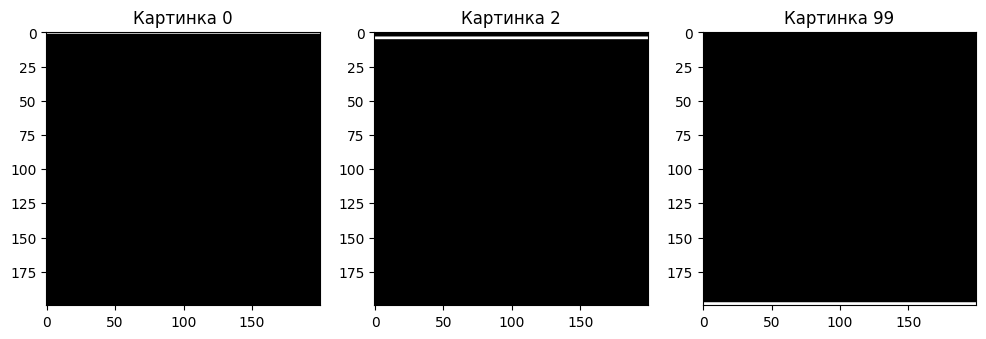

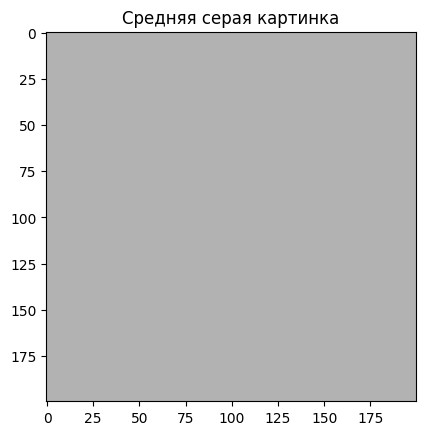

In [18]:
# 1)создание тензора изображений
images = torch.zeros((100, 200, 200, 3), dtype=torch.uint8)

# 2)отрисовка белых полос (2px)
for i in range(100):
    images[i, i * 2 : i * 2 + 2, :, :] = 255

# вывод примеров (0,2,99)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(images[0])
axes[0].set_title("Картинка 0")
axes[1].imshow(images[2])
axes[1].set_title("Картинка 2")
axes[2].imshow(images[99])
axes[2].set_title("Картинка 99")
plt.show()

# 3)среднее по нулевой оси (по картинкам, т.е. 1-й оси в человеческом описании задачи)
mean_image = images.float().mean(dim=0) * 70
plt.imshow(mean_image.int())
plt.title("Средняя серая картинка")
plt.show()

## 3

1. Смените среду выполнения на GPU (в Colab нажмите в меню сверху: `Runtime` -> `Change Runtime Type` -> `GPU`, где изначально стоит `None` (`Среда выполнение` - `Сменить среду выполнения`))

2. Объявите тензор $a$ размера (2, 3, 4) и тензор $b$ размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (`.uniform_()`)

3. Измените форму тензора $b$, чтобы она совпадала с формой тензора $a$, получите тензор $c$.

4. Переместите тензоры $a$ и $c$ на CPU.

5. Объявите тензор `L = torch.mean((c - a) `**` 2)` и посчитайте градиент $L$ по $c$ ( то есть $\frac{\partial{L}}{\partial{c}})$. Выведите градиент $L$ по $c$. Также вычислите его вручную, чтобы проверить себя.

In [15]:
# 2)тензоры a и b на видеокарте
a = torch.empty(2, 3, 4, device=device).uniform_()
b = torch.empty(1, 8, 3, device=device).uniform_()

# 3)изменение формы b в c
c = b.view(2, 3, 4)

# 4) перенос в проц CPU
a = a.cpu()
c = c.cpu()

# 5)вычисление L и градиента dL/dc
c.requires_grad_(True)
L = torch.mean((c - a) ** 2)
L.backward()

print("Автоматический градиент dL/dc:\n", c.grad)

# расчет:
# всего элем. в тензоре N = 2*3*4 = 24
# Формула производной: dL/dc = 2*(c-a)/24 = (c-a)/12
manual_grad = 2 * (c - a) / c.numel()
print("\nРучной градиент dL/dc:\n", manual_grad)
print("\nСовпадают:", torch.allclose(c.grad, manual_grad))

Автоматический градиент dL/dc:
 tensor([[[-0.0371,  0.0229,  0.0202, -0.0397],
         [-0.0673, -0.0646,  0.0048,  0.0326],
         [ 0.0276,  0.0175, -0.0285, -0.0363]],

        [[ 0.0767,  0.0255,  0.0234, -0.0222],
         [-0.0024, -0.0447, -0.0081,  0.0060],
         [-0.0411,  0.0342,  0.0213, -0.0397]]])

Ручной градиент dL/dc:
 tensor([[[-0.0371,  0.0229,  0.0202, -0.0397],
         [-0.0673, -0.0646,  0.0048,  0.0326],
         [ 0.0276,  0.0175, -0.0285, -0.0363]],

        [[ 0.0767,  0.0255,  0.0234, -0.0222],
         [-0.0024, -0.0447, -0.0081,  0.0060],
         [-0.0411,  0.0342,  0.0213, -0.0397]]], grad_fn=<DivBackward0>)

Совпадают: True


# Теория вероятностей (4 балла)

##1

Постройте графики плотности распределений для следующих распределений:

* Биномиальное распределение
* Геометрическое распределение
* Равномерное распределение
* Нормальное распределение
* Логнормальное распределение

Параметры распределений выберите произвольно. Подумайте, какие явления в реальном мире подчиняются тому или иному распределению.

Отобразите также следующие статистические показатели: выборочное среднее, мода, медиана, стандартное отклонение.

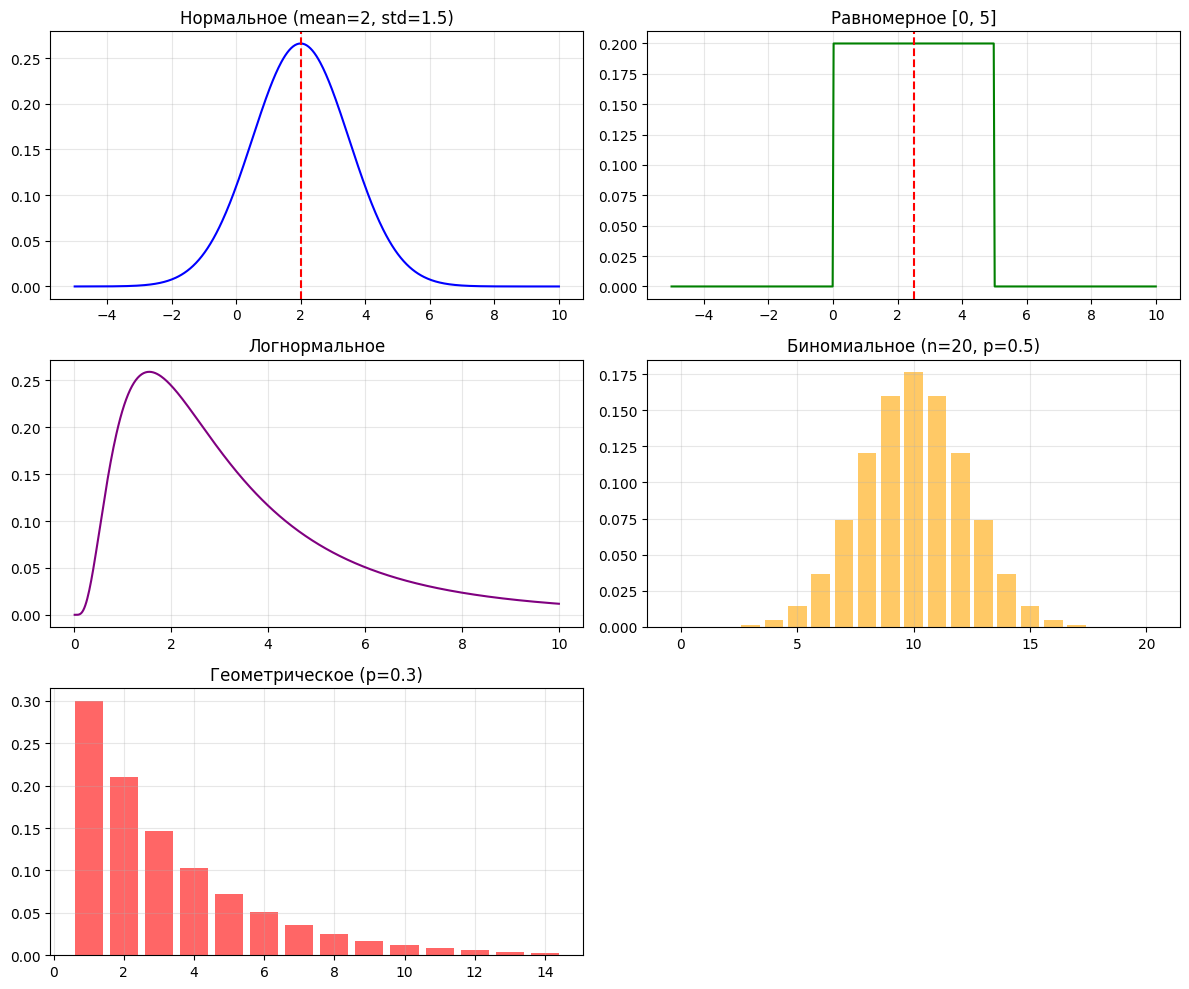

In [6]:
from scipy import stats

# Параметры
x_binom = np.arange(0, 21)
binom_pmf = stats.binom.pmf(x_binom, 20, 0.5)

x_geom = np.arange(1, 15)
geom_pmf = stats.geom.pmf(x_geom, 0.3)

x_cont = np.linspace(-5, 10, 500)
norm_pdf = stats.norm.pdf(x_cont, loc=2, scale=1.5)
uniform_pdf = stats.uniform.pdf(x_cont, loc=0, scale=5)

x_lognorm = np.linspace(0.01, 10, 500)
lognorm_pdf = stats.lognorm.pdf(x_lognorm, s=0.75, scale=np.exp(1))

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# норм
axes[0, 0].plot(x_cont, norm_pdf, color="blue")
axes[0, 0].set_title("Нормальное (mean=2, std=1.5)")
axes[0, 0].axvline(2, color="red", linestyle="--", label="Среднее/Мода/Медиана")

# равномерное
axes[0, 1].plot(x_cont, uniform_pdf, color="green")
axes[0, 1].set_title("Равномерное [0, 5]")
axes[0, 1].axvline(2.5, color="red", linestyle="--", label="Среднее/Медиана")

# логнормальное
axes[1, 0].plot(x_lognorm, lognorm_pdf, color="purple")
axes[1, 0].set_title("Логнормальное")

# биномиальное
axes[1, 1].bar(x_binom, binom_pmf, alpha=0.6, color="orange")
axes[1, 1].set_title("Биномиальное (n=20, p=0.5)")

# Геом етрическое
axes[2, 0].bar(x_geom, geom_pmf, alpha=0.6, color="red")
axes[2, 0].set_title("Геометрическое (p=0.3)")

axes[2, 1].axis("off")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Подумайте, в каких случаях медиана предпочтительнее среднего при расчете "средней температуры по больнице". Какие модификации можно было бы произвести для формулы среднего или для выборки, чтобы среднее значение стало более репрезентативно в подобных случаях? Напишите ответ.

##2 (2 балла)

1000 человек бросают монетку. Каждый бросил 10 раз.

 1. Какова вероятность того, что хотя бы у одного человека монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?
 2. Какова вероятность того, что хотя бы у одного человека монетка выпала 8 раз подряд той же самой стороной (орлом или решкой)?
 3. Какова вероятность того, что ровно у троих человек из 1000 монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?

 Рассчитайте вероятности, а также смоделируйте ситуацию и оцените эмпирическое распределение.

In [9]:
# 1 Задача
# Для 1 чел: P(10 орлов или 10 решек) = 2*(1/2)^10 = 1/512
p_single_10 = 2 * (0.5**10)

#хотя бы один из 1000 с 10 подрядами:
P_at_least_1_of_10 = 1 - (1 - p_single_10) ** 1000

#ровно 3 из 1000:
P_exactly_3_of_10 = stats.binom.pmf(3, 1000, p_single_10)


# Для 8 подряд в 10 бросках у 1 чел

# варианты 8 подряд одного знака из 10:
# ОООOOOOOXX (1,2..8), XOOOOOOOOX, XXOOOOOOOO + аналогич. для решек
# итого 8 благоприятных из 1024
p_single_8 = 8 / 1024
P_at_least_1_of_8 = 1 - (1 - p_single_8) ** 1000

print(f"1. P(хотя бы 1 с 10 подряд) = {P_at_least_1_of_10:.4f}")
print(f"2. P(хотя бы 1 с 8 подряд)  = {P_at_least_1_of_8:.4f}")
print(f"3. P(ровно 3 с 10 подряд)   = {P_exactly_3_of_10:.4f}")

# Эмпирич. моделирование (10к симуляций)
n_sims = 10000
flips = np.random.randint(0, 2, size=(n_sims, 1000, 10))

# подсчет 10 одинаковых
all_same_10 = (flips.sum(axis=2) == 0) | (flips.sum(axis=2) == 10)
count_10_per_sim = all_same_10.sum(axis=1)

emp_at_least_1_10 = np.mean(count_10_per_sim >= 1)
emp_exactly_3_10 = np.mean(count_10_per_sim == 3)

print(
    f"\nЭмпирическая P(хотя бы 1 с 10 подряд): {emp_at_least_1_10:.4f}"
)
print(f"Эмпирическая P(ровно 3 с 10 подряд):  {emp_exactly_3_10:.4f}")

1. P(хотя бы 1 с 10 подряд) = 0.8584
2. P(хотя бы 1 с 8 подряд)  = 0.9996
3. P(ровно 3 с 10 подряд)   = 0.1763

Эмпирическая P(хотя бы 1 с 10 подряд): 0.8591
Эмпирическая P(ровно 3 с 10 подряд):  0.1787


##3

В магазин поступила новая продукция с трех предприятий. Процентный состав этой продукции следующий: 20% - продукция первого предприятия, 30% - продукция второго предприятия, 50% - продукция третьего предприятия; далее, 10% продукции первого предприятия высшего сорта, на втором предприятии - 5% и на третьем - 20% продукции высшего сорта. Найти вероятность того, что случайно купленная новая продукция окажется высшего сорта. Если известно, что купленная продукция высшего сорта, какова вероятность, что она была куплена на втором предприятии?

Решите задачу в общем случае для N предприятий, где доля продукции каждого составляет $a_i$, а доля продукции высшего сорта на каждом составляет $b_i$. Напишите функцию, принимающую на вход два списка: a и b, а также n - номер предприятия, для которого необходимо узнать вероятность, что продукция высшего сорта была куплена именно на нём (нумерация с единицы). Функция должна возвращать две вероятности.

In [10]:
def bayes_factory_prob(a, b, n):
    a = np.array(a)
    b = np.array(b)

    # полн. вероятность высшего сорта
    P_high_quality = np.sum(a * b)

    # вероятность что товар от n-го предприятия (при/если он высш. сорт)
    P_factory_n_given_high = (a[n - 1] * b[n - 1]) / P_high_quality

    return P_high_quality, P_factory_n_given_high


# Рамки из задачи
a_vals = [0.20, 0.30, 0.50]
b_vals = [0.10, 0.05, 0.20]
target_factory = 2

p_total, p_cond = bayes_factory_prob(a_vals, b_vals, target_factory)
print(f"Вероятность высшего сорта: {p_total:.4f}")
print(
    f"Вероятность, что высший сорт со 2-го предприятия: {p_cond:.4f}"
)

Вероятность высшего сорта: 0.1350
Вероятность, что высший сорт со 2-го предприятия: 0.1111


# Методы оптимизации (3 балла)



(Задание взято у Яндекса)

Дана функция $f(x) = (a\sin(x) + b\ln(x))^2 + cx^2$ и файл, содержащий пары (x, f(x)). Необходимо с точностью до трёх знаков после запятой подобрать коэффициенты a, b, c исходной функции. Для решения задачи предлагается использовать градиентный спуск и функцию потерь MSE.

P.S. на предоставленном наборе данных возможно получить MSE < 0.00001, ориентируйтесь на эту цифру.

In [11]:
!gdown 1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3

Downloading...
From: https://drive.google.com/uc?id=1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3
To: /content/data.txt
100% 27.0k/27.0k [00:00<00:00, 77.9MB/s]


In [12]:
with open('data.txt', 'r') as file:
    x_data = []
    y_data = []
    for para in eval(file.read()):
        x_data.append(para[0])
        y_data.append(para[1])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [13]:
import torch

x_t = torch.tensor(x_data, dtype=torch.float32)
y_t = torch.tensor(y_data, dtype=torch.float32)

a = torch.tensor([1.0], requires_grad=True, dtype=torch.float32)
b = torch.tensor([1.0], requires_grad=True, dtype=torch.float32)
c = torch.tensor([1.0], requires_grad=True, dtype=torch.float32)

optimizer = torch.optim.Adam([a, b, c], lr=0.01)

for epoch in range(15000):
    optimizer.zero_grad()

    # f(x) = (a*sin(x) + b*ln(x))^2 + c*x^2
    y_pred = (a * torch.sin(x_t) + b * torch.log(x_t)) ** 2 + c * (
        x_t**2
    )

    loss = torch.mean((y_pred - y_t) ** 2)
    loss.backward()
    optimizer.step()

    if epoch % 3000 == 0 or loss.item() < 0.00001:
        if loss.item() < 0.00001:
            print(f"целевой mse достингут на шаге {epoch}: {loss.item():.6f}")
            break

print(
    f"\nПодобранные коэфы:\n a={a.item():.3f}\n b={b.item():.3f}\n c={c.item():.3f}"
)
print(f"Конечный mse: {loss.item():.6f}")

целевой mse достингут на шаге 1260: 0.000010

Подобранные коэфы:
 a=3.142
 b=2.719
 c=4.000
Конечный mse: 0.000010
